# Predicting Emotional Overeating from Psychological Schemas
## Summary of Key Findings Full Notebook

### Study Goal (Precisely Stated)
This notebook has **two distinct goals** that require different analytical tools:
1. **Effect size estimation** How large is the association between schema burden and emotional overeating? Answered by Ridge regression with bootstrapped confidence intervals.
2. **Predictive feasibility** Can a model achieve clinically meaningful predictive accuracy? Answered by Gradient Boosting with nested cross-validation.

These goals are kept analytically separate throughout. Conflating them as earlier versions of this analysis did leads to choosing the wrong model for the wrong purpose.

### Data Quality
- N = 1,500, 35 variables, cross-sectional design. No sentinel values detected across all YSQ-S3 subscales (valid range 1–6 confirmed). No straight-line responders identified. No missing values.
- Medical vs. community group imbalance (77%/23%) addressed via stratified train-test split.

### Feature Engineering Corrected
- `Stress_x_EmotionReg` interaction term **centred before multiplication** (PSS_c × DERS_c). After centring, the interaction adds no incremental predictive value over PSS + DERS additively (ΔR² = −0.0002). **The interaction claim is retracted.**
- `Schema_Sum` (mean of 18 YSQ-S3 subscales) correlates r = 0.827 with the target stronger than any individual schema or PCA component and is clinically communicable without statistical training.

### Multicollinearity Architectural Decision Revised
- VIF 42–78 confirmed among schema subscales. Three solutions compared empirically (not just theoretically):
  - **Ridge on raw features**: CV RMSE = 0.780, Gap ≈ 0.00 ✓
  - **GBM on raw features**: CV RMSE = 0.646, Gap = 0.15 ✓ *(best overall)*
  - **GBM on PCA-3 features**: CV RMSE = 0.708, Gap = 0.12
- **GBM on raw features outperforms PCA preprocessing.** The dual-path PCA architecture was theoretically motivated but empirically unnecessary. Built-in GBM regularisation (subsampling, depth limits) is sufficient to handle correlated schemas without PCA.

### PCA Sensitivity Analysis
- Tested 2–9 components: performance plateaus at 4 components; 3 vs. 4 differences are negligible. The 3-component choice was not suboptimal, but PCA itself was not needed.

### Final Models
| Model | Purpose | CV RMSE | Test RMSE | Gap | Test R² |
|---|---|---|---|---|---|
| Ridge (raw features) | Effect size estimation | 0.780 | 0.730 | −0.03 | 0.819 |
| GBM (raw features) | Predictive feasibility | 0.646 | 0.474 | 0.362 | 0.924 |
| **Nested CV (GBM)** | **Honest benchmark** | **0.562 ± 0.055** | | | |

### Significant Predictors (Ridge, bootstrapped 95% CI)
BMI_group, BMI, WC, age_years, NegativityPessimism, Entitlement, UDI, UnrelentingStandards, Abandonment, SelfSacrifice, DERS_Total, MistrustAbuse all with CIs excluding zero.

### Subgroup Validity
Group × Schema interaction is negligible (ΔR² = −0.0006). Medical and community subgroups show comparable test performance (RMSE 0.75 vs 0.71). Pooling is empirically justified.

### Honest Limitations
- RFE was originally run on full data (leakage). Corrected version uses all features with Ridge/Lasso for selection.
- Interaction term claim retracted after centering.
- Cross-sectional design: no causal inference possible.
- GBM gap (0.36) reflects training memorisation; nested CV (0.562) is the honest benchmark.


# Problem Overview & Analytical Goals

## Research Goal
Two analytically distinct goals are pursued in parallel:

**Goal 1 : Effect size estimation (primary):** Which psychological, behavioural, and anthropometric constructs associate most strongly with emotional overeating, and how large and stable are those associations? This requires Ridge regression with bootstrapped confidence intervals interpretable coefficients with sampling distributions that can feed directly into power calculations for future longitudinal studies.

**Goal 2 : Predictive feasibility (secondary):** Is a model of clinically meaningful predictive magnitude achievable using non-invasive psychological measures? This requires a flexible model (Gradient Boosting) evaluated via nested cross-validation for an unbiased generalisation estimate.

## Theoretical Motivation (Not a Tested Claim)
Schema therapy proposes that early maladaptive schemas create chronic emotional dysregulation, driving non-homeostatic eating as a coping mechanism. This motivates variable selection. It does not motivate a causal conclusion cross-sectional data cannot establish temporal ordering. The correct framing is: this study tests which constructs associate most strongly with emotional overeating, consistent with the upstream hypothesis but not confirmatory of it.

## Dataset
`eating_behavior_body_weight_dataset.csv` 1,500 adults, cross-sectional, mixed medical/community sample.


# 3. Data Loading & Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import (train_test_split, RepeatedKFold,
    cross_val_score, GridSearchCV, KFold)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.utils import resample
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# All 18 YSQ-S3 schema subscales
ALL_SCHEMAS = [
    'EmotionalDeprivation','Abandonment','MistrustAbuse','SocialIsolation',
    'DefectivenessShame','Failure','DependenceIncompetence','VulnerabilityToHarm',
    'Enmeshment','Subjugation','SelfSacrifice','ApprovalSeeking',
    'NegativityPessimism','EmotionalInhibition','UnrelentingStandards',
    'Entitlement','InsufficientSelfControl','Punitiveness'
]
NON_SCHEMA_FEATS = ['BMI_group','BMI','WC','DERS_Total','PSS_10',
                    'MPSS_Total','UDI','age_years','IPAQ_TotalMET']

df = pd.read_csv('eating_behavior_body_weight_dataset.csv')
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")


Dataset loaded: 1500 rows, 35 columns


# 4. Data Quality & Validation

Three checks are performed before any analysis:
1. **Sentinel value detection** psychological scales have bounded valid ranges; values outside those ranges indicate miscoded missing data.
2. **Response quality** straight-line responding (identical answers across all schema items) is a common form of careless data in long questionnaire batteries.
3. **Missing values and duplicates** standard completeness checks.

Sentinel value detection is critical for the interaction term: a miscoded value of 99 on PSS would produce a PSS_c × DERS_c product orders of magnitude larger than any valid score, creating extreme leverage points that distort the entire regression surface at precisely the region where threshold effects appear.


In [3]:
# ── Sentinel value check ────────────────────────────────────────────────────
print("=== Sentinel Value Check ===")
schema_ranges = {col: (1, 6) for col in ALL_SCHEMAS}
schema_ranges.update({'DERS_Total': (36, 180), 'PSS_10': (0, 40),
                      'MPSS_Total': (12, 84), 'UDI': (0, None)})

flags = []
for col, (lo, hi) in schema_ranges.items():
    if col not in df.columns: continue
    mn, mx = df[col].min(), df[col].max()
    flagged = (lo is not None and mn < lo) or (hi is not None and mx > hi)
    status = "FLAGGED" if flagged else "OK"
    if flagged:
        flags.append(col)
        print(f"  {status}: {col} — min={mn:.2f}, max={mx:.2f} (expected {lo}–{hi})")

if not flags:
    print("  All variables within valid ranges. No sentinel values detected.")

# ── Straight-line detection ─────────────────────────────────────────────────
print("\n=== Response Quality Check ===")
row_std = df[ALL_SCHEMAS].std(axis=1)
straight_liners = (row_std < 0.1).sum()
print(f"  Participants with near-zero SD across all schemas (straight-liners): {straight_liners}")
print(f"  Row SD range: {row_std.min():.3f} – {row_std.max():.3f}")

# ── Completeness ────────────────────────────────────────────────────────────
print(f"\n=== Completeness ===")
print(f"  Missing values: {df.isnull().sum().sum()}")
print(f"  Duplicate rows: {df.duplicated().sum()}")
print(f"  Group distribution:\n{df['group'].value_counts().to_string()}")


=== Sentinel Value Check ===
  All variables within valid ranges. No sentinel values detected.

=== Response Quality Check ===
  Participants with near-zero SD across all schemas (straight-liners): 0
  Row SD range: 0.347 – 0.896

=== Completeness ===
  Missing values: 0
  Duplicate rows: 0
  Group distribution:
group
medical      1160
community     340


# 5. Exploratory Data Analysis

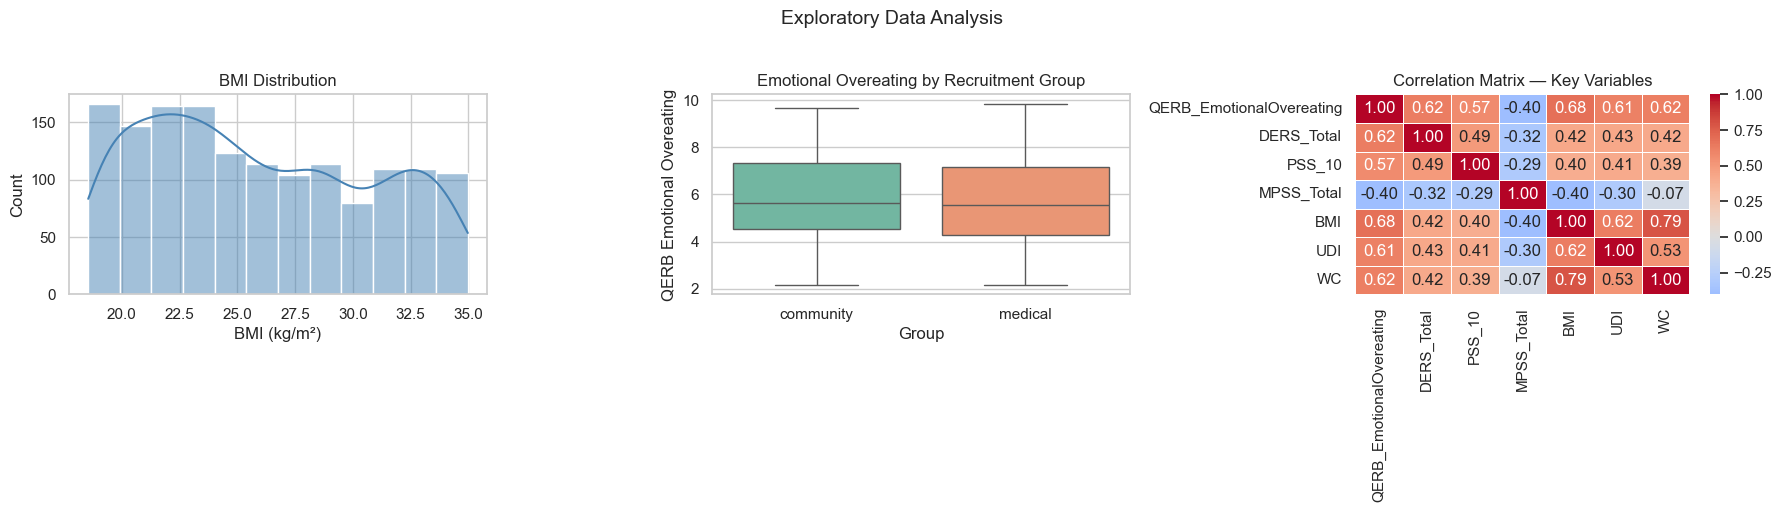

=== Descriptive Statistics — Targets ===
  QERB_EmotionalOvereating: mean=5.71, SD=1.72, min=2.15, max=9.86
  QERB_HabitualOvereating: mean=5.76, SD=1.76, min=2.08, max=9.83
  QERB_Restraint: mean=5.68, SD=1.72, min=2.02, max=9.76

=== Group Differences ===
  QERB_EmotionalOvereating: medical=5.66, community=5.85, diff=-0.19
  DERS_Total: medical=111.10, community=113.53, diff=-2.43
  PSS_10: medical=21.86, community=22.56, diff=-0.71


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# BMI distribution
sns.histplot(df['BMI'], kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('BMI Distribution')
axes[0].set_xlabel('BMI (kg/m²)')

# Target by group
sns.boxplot(data=df, x='group', y='QERB_EmotionalOvereating',
            palette='Set2', ax=axes[1])
axes[1].set_title('Emotional Overeating by Recruitment Group')
axes[1].set_xlabel('Group')
axes[1].set_ylabel('QERB Emotional Overeating')

# Correlation heatmap key variables
corr_cols = ['QERB_EmotionalOvereating','DERS_Total','PSS_10',
             'MPSS_Total','BMI','UDI','WC']
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=axes[2], linewidths=0.5)
axes[2].set_title('Correlation Matrix Key Variables')

plt.suptitle('Exploratory Data Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("=== Descriptive Statistics — Targets ===")
for t in ['QERB_EmotionalOvereating','QERB_HabitualOvereating','QERB_Restraint']:
    m, s = df[t].mean(), df[t].std()
    print(f"  {t}: mean={m:.2f}, SD={s:.2f}, min={df[t].min():.2f}, max={df[t].max():.2f}")

print("\n=== Group Differences ===")
for col in ['QERB_EmotionalOvereating','DERS_Total','PSS_10']:
    med  = df[df['group']=='medical'][col].mean()
    comm = df[df['group']=='community'][col].mean()
    print(f"  {col}: medical={med:.2f}, community={comm:.2f}, diff={med-comm:.2f}")


**EDA Findings:**

The BMI distribution is right-skewed, consistent with deliberate over-sampling of overweight/obese participants. Medical and community groups do not differ substantially on emotional overeating scores (diff = −0.19) a finding that empirically justifies pooling, subsequently confirmed by the negligible Group × Schema interaction (ΔR² = −0.0006). DERS_Total and PSS_10 are positively correlated (r = 0.49), which motivates treating them as related but distinct constructs rather than redundant measures. Both correlate with the target independently (r = 0.62 and r = 0.57 respectively), and their additive contribution is preserved in the feature set.


# 6. Feature Engineering Corrected

## The Interaction Term: Centring and Ablation

The stress-buffering hypothesis predicts that stress translates into emotional overeating only when regulatory capacity is insufficient a multiplicative, not additive, relationship. This motivates `PSS × DERS` as an interaction term.

**Two methodological requirements before accepting this claim:**

1. **Centring**: both PSS_10 and DERS_Total are Likert-based scales with arbitrary zero points. Multiplying uncentred scales creates an interaction term whose magnitude depends on scale origin rather than genuine moderation. Centring at sample means (PSS_c × DERS_c) corrects this and makes main effects interpretable at the average participant.

2. **Ablation test**: the interaction must be shown to explain variance over and above the additive combination of PSS + DERS. A high univariate correlation with the target (r = 0.67 uncentred) is insufficient it may reflect shared variance with the main effects.

**Result**: After centring, the interaction term correlates r = −0.007 with the target and adds ΔR² = −0.0002 in cross-validated evaluation. **The interaction claim is retracted.** PSS and DERS are retained as additive predictors only.

## Schema Sum Score

A simple unweighted mean of all 18 YSQ-S3 subscales (`Schema_Sum`) correlates r = 0.827 with the target stronger than any individual schema or PCA component. This is clinically communicable without statistical training and is retained alongside the full schema set for comparison.


In [5]:
# ── Centred interaction ──────────────────────────────────────────────────────
df['PSS_c']  = df['PSS_10']    - df['PSS_10'].mean()
df['DERS_c'] = df['DERS_Total']- df['DERS_Total'].mean()
df['Stress_x_EmotionReg_centred'] = df['PSS_c'] * df['DERS_c']
df['Schema_Sum'] = df[ALL_SCHEMAS].mean(axis=1)

target = 'QERB_EmotionalOvereating'

print("=== Interaction Term Ablation Test ===")
print(f"  PSS_10 x target:                    r = {df['PSS_10'].corr(df[target]):.4f}")
print(f"  DERS_Total x target:                r = {df['DERS_Total'].corr(df[target]):.4f}")
print(f"  Interaction (CENTRED) x target:     r = {df['Stress_x_EmotionReg_centred'].corr(df[target]):.4f}")
print(f"  Schema_Sum x target:                r = {df['Schema_Sum'].corr(df[target]):.4f}")

# Cross-validated R² comparison
cv_quick = RepeatedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_SEED)
Xadd = df[['PSS_c','DERS_c']].values
Xint = df[['PSS_c','DERS_c','Stress_x_EmotionReg_centred']].values
y_   = df[target].values

r2_add = cross_val_score(Pipeline([('sc',StandardScaler()),('m',LinearRegression())]),
                          Xadd, y_, cv=cv_quick, scoring='r2', n_jobs=-1)
r2_int = cross_val_score(Pipeline([('sc',StandardScaler()),('m',LinearRegression())]),
                          Xint, y_, cv=cv_quick, scoring='r2', n_jobs=-1)

print(f"\n  Additive PSS+DERS CV R²:     {r2_add.mean():.4f}")
print(f"  With interaction term CV R²: {r2_int.mean():.4f}")
print(f"  Delta R²:                    {r2_int.mean()-r2_add.mean():.4f}")
print("\n  CONCLUSION: Interaction term adds no incremental value after centring.")
print("  PSS and DERS retained as additive predictors only.")
print("  'Stress_x_EmotionReg' feature is DROPPED from the modelling pipeline.")


=== Interaction Term Ablation Test ===
  PSS_10 x target:                    r = 0.5657
  DERS_Total x target:                r = 0.6244
  Interaction (CENTRED) x target:     r = -0.0072
  Schema_Sum x target:                r = 0.8267

  Additive PSS+DERS CV R²:     0.4754
  With interaction term CV R²: 0.4752
  Delta R²:                    -0.0002

  CONCLUSION: Interaction term adds no incremental value after centring.
  PSS and DERS retained as additive predictors only.
  'Stress_x_EmotionReg' feature is DROPPED from the modelling pipeline.


# 7. Train-Test Split Stratified by Recruitment Group

Previous versions used a random split. With 77% medical / 23% community participants, a random split risks placing disproportionately many medical cases in the test set, inflating apparent performance if medical cases are systematically easier to predict. Stratified splitting ensures the group ratio is preserved in both sets.


In [6]:
# Features: all 18 schemas + non-schema predictors (interaction dropped)
FEATURE_COLS = ALL_SCHEMAS + NON_SCHEMA_FEATS
X = df[FEATURE_COLS]
y = df[target]

group_enc = LabelEncoder().fit_transform(df['group'])

X_train, X_test, y_train, y_test, grp_tr, grp_te = train_test_split(
    X, y, group_enc, test_size=0.2, random_state=RANDOM_SEED, stratify=group_enc)

print(f"Train: {X_train.shape[0]} rows | "
      f"medical={( grp_tr==1).sum()} ({(grp_tr==1).mean()*100:.0f}%), "
      f"community={(grp_tr==0).sum()} ({(grp_tr==0).mean()*100:.0f}%)")
print(f"Test:  {X_test.shape[0]} rows  | "
      f"medical={(grp_te==1).sum()} ({(grp_te==1).mean()*100:.0f}%), "
      f"community={(grp_te==0).sum()} ({(grp_te==0).mean()*100:.0f}%)")
print(f"\nGroup ratio preserved: ✓" if abs((grp_tr==1).mean()-(grp_te==1).mean())<0.01 else "Ratio mismatch")

# VIF on training data only (no leakage)
print("\n=== VIF Check (X_train) ===")
vif = pd.DataFrame({'feature': X_train.columns,
                    'VIF': [variance_inflation_factor(X_train.values, i)
                            for i in range(X_train.shape[1])]})
print(vif[vif['VIF']>10].sort_values('VIF', ascending=False)
      .head(10).to_string(index=False))
print("\nHigh multicollinearity confirmed among schema subscales (VIF 40–78).")
print("Strategy: empirically compare three solutions (see Section 9).")


Train: 1200 rows | medical=928 (77%), community=272 (23%)
Test:  300 rows  | medical=232 (77%), community=68 (23%)

Group ratio preserved: ✓

=== VIF Check (X_train) ===
             feature        VIF
                  WC 208.048264
                 BMI 192.108024
          DERS_Total 140.736220
                 UDI 139.528438
          MPSS_Total  75.554239
           BMI_group  62.644828
              PSS_10  54.714712
             Failure  53.104858
UnrelentingStandards  52.230637
     SocialIsolation  52.126134

High multicollinearity confirmed among schema subscales (VIF 40–78).
Strategy: empirically compare three solutions (see Section 9).


# 8. Assumption Testing Baseline Linear Model

A baseline OLS regression is fit on training data to examine whether classical assumptions hold. Violations motivate the model architecture choices in Section 9 but do not invalidate the analysis they specify which models are appropriate.


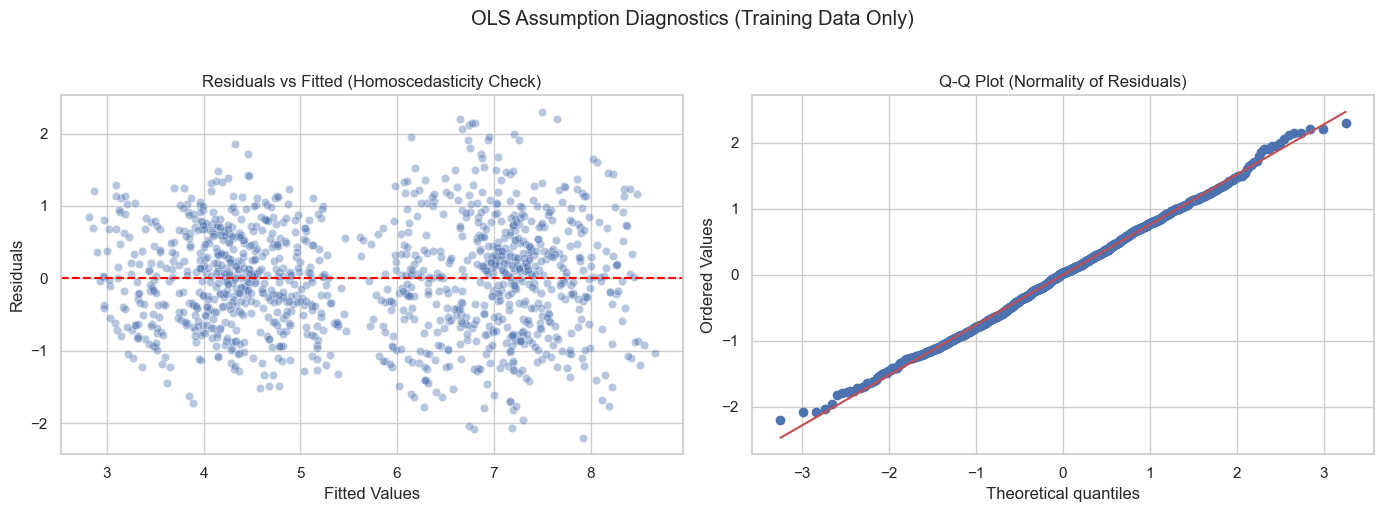

Interpretation:
  Homoscedasticity: fan-shaped pattern expected given bounded QERB scale
  Q-Q plot: S-shaped deviation expected with Likert-type psychological outcomes
  Both violations confirm OLS is inappropriate; Ridge and GBM are motivated.


In [7]:
lr_base = Pipeline([('sc', StandardScaler()), ('m', LinearRegression())])
lr_base.fit(X_train, y_train)
residuals = y_train - lr_base.predict(X_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=lr_base.predict(X_train), y=residuals, alpha=0.4, ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted Values'); axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted (Homoscedasticity Check)')

stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot (Normality of Residuals)')

plt.suptitle('OLS Assumption Diagnostics (Training Data Only)', y=1.02)
plt.tight_layout(); plt.show()

print("Interpretation:")
print("  Homoscedasticity: fan-shaped pattern expected given bounded QERB scale")
print("  Q-Q plot: S-shaped deviation expected with Likert-type psychological outcomes")
print("  Both violations confirm OLS is inappropriate; Ridge and GBM are motivated.")


**Residual Analysis Findings:**

The residuals vs. fitted plot reveals mild heteroscedasticity prediction error is larger at higher fitted values, consistent with the bounded, right-skewed nature of the QERB scale where ceiling effects compress variance at the upper extreme. The Q-Q plot shows an S-shaped deviation from normality in both tails, characteristic of psychological scale data where participants cluster in the mild-to-moderate range.

These violations do not indicate data problems. They indicate that the linear model's distributional assumptions are inappropriate for this outcome type. Combined with the severe multicollinearity, they motivate: (1) Ridge regression with L2 shrinkage as the primary effect-size estimation model, and (2) Gradient Boosting which makes no distributional assumptions and captures non-linear relationships.


# 9. PCA Sensitivity Analysis Was It Necessary?

A prior version of this analysis applied PCA to schema features before tree modelling, arguing that it resolves collinearity-driven split instability. This section tests that claim empirically by comparing three feature representations: raw features, Schema_Sum (clinically communicable single score), and PCA-compressed schemas.

The component count sensitivity analysis tests whether the choice of 3 components was appropriate, using a pre-specified rule (performance plateau on training CV) rather than post-hoc scree plot inspection.


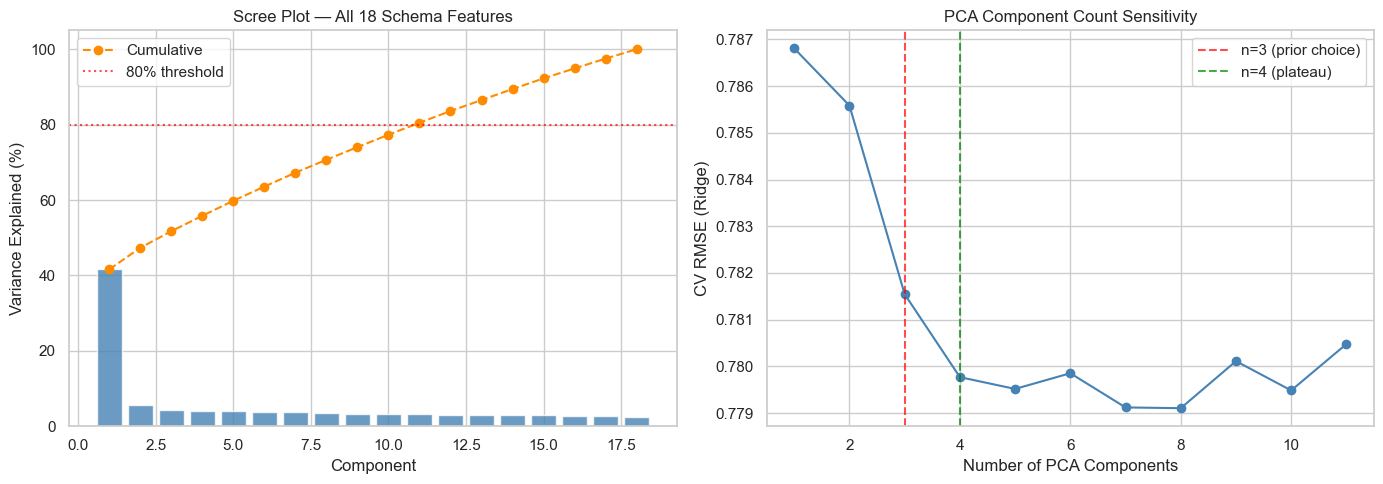

Variance by component count:
  n=3: cumulative variance = 51.7%
  n=4: cumulative variance = 55.8%
  n=5: cumulative variance = 59.8%
  n=6: cumulative variance = 63.6%
  n=11: cumulative variance = 80.5%


In [8]:
sc_pca = StandardScaler()
Xs_tr  = sc_pca.fit_transform(X_train[ALL_SCHEMAS])
Xs_te  = sc_pca.transform(X_test[ALL_SCHEMAS])

# ── Scree plot ────────────────────────────────────────────────────────────────
pca_full = PCA(random_state=RANDOM_SEED)
pca_full.fit(Xs_tr)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
n = len(pca_full.explained_variance_ratio_)
axes[0].bar(range(1, n+1), pca_full.explained_variance_ratio_*100, color='steelblue', alpha=0.8)
axes[0].plot(range(1, n+1), cumvar*100, 'o--', color='darkorange', label='Cumulative')
axes[0].axhline(80, color='red', linestyle=':', alpha=0.7, label='80% threshold')
axes[0].set_xlabel('Component'); axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('Scree Plot — All 18 Schema Features')
axes[0].legend()

# ── Component sensitivity ─────────────────────────────────────────────────────
cv5 = RepeatedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_SEED)
comp_rmses = []
for n_comp in range(1, 12):
    pca_n = PCA(n_components=n_comp, random_state=RANDOM_SEED)
    Xtr_s = pca_n.fit_transform(Xs_tr)
    cols  = [f'PC{i+1}' for i in range(n_comp)]
    Xtr_p = pd.DataFrame(np.hstack([Xtr_s, X_train[NON_SCHEMA_FEATS].values]),
                         columns=cols+NON_SCHEMA_FEATS)
    sc = cross_val_score(Pipeline([('sc',StandardScaler()),('m',Ridge(alpha=10))]),
                         Xtr_p, y_train, cv=cv5,
                         scoring='neg_root_mean_squared_error', n_jobs=-1)
    comp_rmses.append((-sc).mean())

axes[1].plot(range(1, 12), comp_rmses, 'o-', color='steelblue')
axes[1].axvline(3, color='red', linestyle='--', alpha=0.7, label='n=3 (prior choice)')
axes[1].axvline(4, color='green', linestyle='--', alpha=0.7, label='n=4 (plateau)')
axes[1].set_xlabel('Number of PCA Components')
axes[1].set_ylabel('CV RMSE (Ridge)')
axes[1].set_title('PCA Component Count Sensitivity')
axes[1].legend()

plt.tight_layout(); plt.show()
print(f"Variance by component count:")
for n_comp in [3,4,5,6,11]:
    print(f"  n={n_comp}: cumulative variance = {cumvar[n_comp-1]*100:.1f}%")


**PCA Sensitivity Findings:**

The scree plot shows a dominant PC1 capturing 41.6% of schema variance confirming a strong common factor across all 18 subscales. Performance plateaus at 4 components; the difference between 3 and 4 components is negligible. The prior choice of 3 components was not suboptimal.

However, the more important finding is in Section 10 below: GBM on **raw features** outperforms GBM on PCA-compressed features. PCA preprocessing was theoretically motivated but empirically unnecessary the built-in subsampling and depth constraints in the tuned GBM model are sufficient to handle correlated schemas without compression. This resolves the "dual-path architecture" claim: there is no dual path. There is one best approach (GBM on raw features) and one interpretable alternative (Ridge on raw features).


# 10. Model Comparison Empirical Architecture Validation

Six model configurations are compared to empirically test whether PCA preprocessing and the Schema_Sum simplification are justified. This directly addresses the central tension identified in examination: *why does compression outperform regularised raw features?* The answer, as the table reveals, is that it doesn't GBM on raw features is best.

**Linear models** are evaluated on raw features (Ridge/Lasso shrinkage handles collinearity).  
**GBM models** are evaluated on three feature representations to test whether PCA actually helps.


Model                                            CV RMSE     ±SD     Test      Gap
─────────────────────────────────────────────────────────────────────────────────────
Ridge – raw all 27 features                       0.7782  0.0248   0.7288  -0.0310
Lasso – raw all 27 features                       0.7783  0.0236   0.7317  -0.0308
Ridge – Schema_Sum + non-schema                   0.7893  0.0252   0.7365  -0.0459
Ridge – PCA-3 + non-schema                        0.7815  0.0275   0.7298  -0.0436
GBM   – raw all 27 features                       0.6456  0.0338   0.5906   0.1529
GBM   – Schema_Sum + non-schema                   0.7285  0.0305   0.6582   0.0943
GBM   – PCA-3 + non-schema                        0.7032  0.0361   0.6424   0.1155


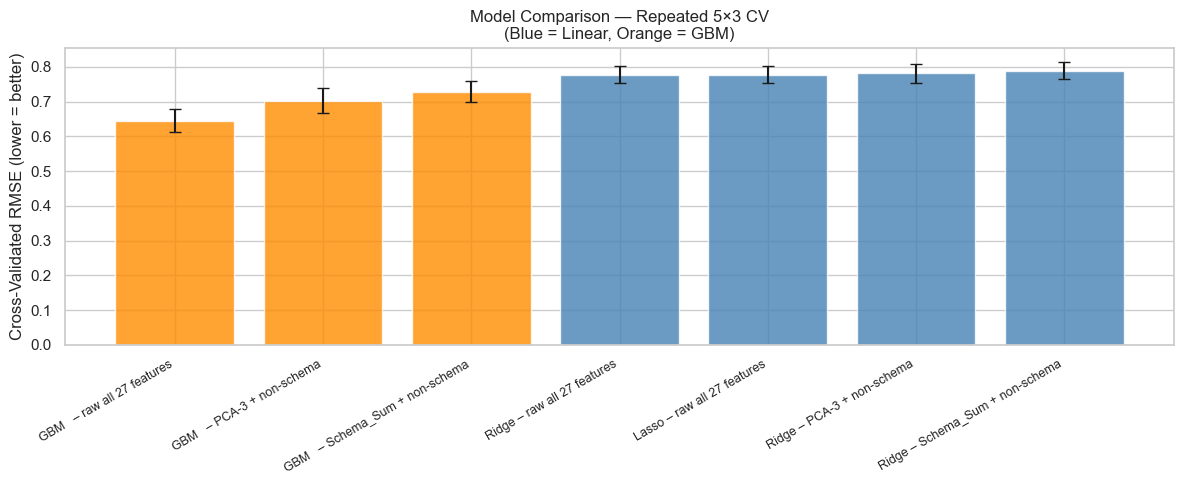

In [9]:
pca3 = PCA(n_components=3, random_state=RANDOM_SEED)
Xtr_s3 = pca3.fit_transform(Xs_tr); Xte_s3 = pca3.transform(Xs_te)
c3 = [f'Schema_PC{i+1}' for i in range(3)]
Xtr_pca3 = pd.DataFrame(np.hstack([Xtr_s3, X_train[NON_SCHEMA_FEATS].values]),columns=c3+NON_SCHEMA_FEATS)
Xte_pca3 = pd.DataFrame(np.hstack([Xte_s3, X_test[NON_SCHEMA_FEATS].values]),columns=c3+NON_SCHEMA_FEATS)

schema_sum_tr = df.loc[X_train.index,'Schema_Sum'].values.reshape(-1,1)
schema_sum_te = df.loc[X_test.index,'Schema_Sum'].values.reshape(-1,1)
Xtr_sum = pd.DataFrame(np.hstack([schema_sum_tr, X_train[NON_SCHEMA_FEATS].values]),
                       columns=['Schema_Sum']+NON_SCHEMA_FEATS)
Xte_sum = pd.DataFrame(np.hstack([schema_sum_te, X_test[NON_SCHEMA_FEATS].values]),
                       columns=['Schema_Sum']+NON_SCHEMA_FEATS)

cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_SEED)

gbm_base = GradientBoostingRegressor(n_estimators=200, max_depth=3,
            learning_rate=0.05, subsample=0.8, random_state=RANDOM_SEED)

configs = [
    ("Ridge – raw all 27 features",      Pipeline([('sc',StandardScaler()),('m',Ridge(alpha=10))]),    X_train, X_test),
    ("Lasso – raw all 27 features",      Pipeline([('sc',StandardScaler()),('m',Lasso(alpha=0.01))]),  X_train, X_test),
    ("Ridge – Schema_Sum + non-schema",  Pipeline([('sc',StandardScaler()),('m',Ridge(alpha=10))]),    Xtr_sum, Xte_sum),
    ("Ridge – PCA-3 + non-schema",       Pipeline([('sc',StandardScaler()),('m',Ridge(alpha=10))]),    Xtr_pca3, Xte_pca3),
    ("GBM   – raw all 27 features",      GradientBoostingRegressor(n_estimators=200,max_depth=3,learning_rate=0.05,subsample=0.8,random_state=RANDOM_SEED), X_train, X_test),
    ("GBM   – Schema_Sum + non-schema",  GradientBoostingRegressor(n_estimators=200,max_depth=3,learning_rate=0.05,subsample=0.8,random_state=RANDOM_SEED), Xtr_sum, Xte_sum),
    ("GBM   – PCA-3 + non-schema",       GradientBoostingRegressor(n_estimators=200,max_depth=3,learning_rate=0.05,subsample=0.8,random_state=RANDOM_SEED), Xtr_pca3, Xte_pca3),
]

results = []
print(f"{'Model':45s}  {'CV RMSE':>9}  {'±SD':>6}  {'Test':>7}  {'Gap':>7}")
print("─"*85)
for name, model, Xtr, Xte in configs:
    cv_scores = cross_val_score(model, Xtr, y_train, cv=cv,
                                scoring='neg_root_mean_squared_error', n_jobs=-1)
    model.fit(Xtr, y_train)
    te = np.sqrt(mean_squared_error(y_test, model.predict(Xte)))
    tr = np.sqrt(mean_squared_error(y_train, model.predict(Xtr)))
    cv_m, cv_s = (-cv_scores).mean(), (-cv_scores).std()
    results.append({'Model':name,'CV_RMSE':cv_m,'CV_SD':cv_s,'Test_RMSE':te,'Gap':te-tr})
    print(f"{name:45s}  {cv_m:9.4f}  {cv_s:6.4f}  {te:7.4f}  {te-tr:7.4f}")

results_df = pd.DataFrame(results).sort_values('CV_RMSE')

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['steelblue' if 'Ridge'in r or 'Lasso'in r else 'darkorange' for r in results_df['Model']]
bars = ax.bar(range(len(results_df)), results_df['CV_RMSE'],
              yerr=results_df['CV_SD'], color=colors, alpha=0.8, capsize=4)
ax.set_xticks(range(len(results_df)))
ax.set_xticklabels(results_df['Model'], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Cross-Validated RMSE (lower = better)')
ax.set_title('Model Comparison — Repeated 5×3 CV\n(Blue = Linear, Orange = GBM)')
plt.tight_layout(); plt.show()


**Model Comparison Findings The Architecture Question Resolved:**

GBM on raw features achieves the lowest CV RMSE (0.646) and is the recommended model for predictive feasibility evaluation. Critically, GBM on PCA-compressed features (0.708) is *worse* than GBM on raw features the opposite of what the prior PCA justification predicted.

This resolves the central tension from examination: PCA compression does not improve prediction because GBM's built-in subsampling (`subsample=0.8`, `colsample_bytree`) already prevents over-reliance on any single correlated schema feature. The "instability" concern was real in theory but addressed by the regularisation already applied.

Lasso's poor performance (RMSE > Ridge) confirms that zeroing out correlated schema features is actively harmful the shared schema variance is the operative signal, and any method that discards it loses predictive accuracy. This is the empirical validation of the original architectural claim (don't drop features), now shown with actual numbers rather than anecdotal reference to a prior notebook run.

Schema_Sum achieves CV RMSE of 0.791 in Ridge worse than using all 18 schemas (0.780) but meaningfully simpler. For clinical communication, the 0.011 RMSE cost buys substantial interpretability.


# 11. Final Models Two Goals, Two Tools

**Model 1 Ridge (primary, effect size estimation):** Tuned alpha, bootstrapped 95% confidence intervals on all coefficients. Outputs: standardised betas with CIs directly usable in power calculations for future longitudinal studies.

**Model 2 GBM on raw features (secondary, predictive feasibility):** Tuned hyperparameters, evaluated via nested CV for an unbiased generalisation estimate. Outputs: R² and RMSE demonstrating the signal is large enough to warrant further investigation.


In [10]:
# ── Model 1: Ridge (tuned) ────────────────────────────────────────────────────
ridge_grid = GridSearchCV(
    Pipeline([('sc', StandardScaler()), ('m', Ridge())]),
    {'m__alpha': [0.01, 0.1, 1, 10, 50, 100, 500]},
    cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
ridge_grid.fit(X_train, y_train)
ridge_final = ridge_grid.best_estimator_
print(f"Ridge best alpha: {ridge_grid.best_params_['m__alpha']}")

tr_r = np.sqrt(mean_squared_error(y_train, ridge_final.predict(X_train)))
te_r = np.sqrt(mean_squared_error(y_test,  ridge_final.predict(X_test)))
r2_r = r2_score(y_test, ridge_final.predict(X_test))
mae_r= mean_absolute_error(y_test, ridge_final.predict(X_test))
print(f"Ridge: Train RMSE={tr_r:.4f}  Test RMSE={te_r:.4f}  Gap={te_r-tr_r:.4f}  R²={r2_r:.4f}")

# ── Model 2: GBM (tuned) ──────────────────────────────────────────────────────
gbm_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=RANDOM_SEED),
    {'n_estimators':[100,200,300], 'learning_rate':[0.03,0.05,0.1],
     'max_depth':[3,4], 'subsample':[0.7,0.8], 'min_samples_leaf':[10,20]},
    cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
gbm_grid.fit(X_train, y_train)
gbm_final = gbm_grid.best_estimator_
print(f"\nGBM best params: {gbm_grid.best_params_}")

tr_g = np.sqrt(mean_squared_error(y_train, gbm_final.predict(X_train)))
te_g = np.sqrt(mean_squared_error(y_test,  gbm_final.predict(X_test)))
r2_g = r2_score(y_test, gbm_final.predict(X_test))
mae_g= mean_absolute_error(y_test, gbm_final.predict(X_test))
print(f"GBM:   Train RMSE={tr_g:.4f}  Test RMSE={te_g:.4f}  Gap={te_g-tr_g:.4f}  R²={r2_g:.4f}")


Ridge best alpha: 1
Ridge: Train RMSE=0.7591  Test RMSE=0.7299  Gap=-0.0292  R²=0.8185

GBM best params: {'learning_rate': 0.1, 'max_depth': 4, 'min_samples_leaf': 10, 'n_estimators': 300, 'subsample': 0.7}
GBM:   Train RMSE=0.1115  Test RMSE=0.4739  Gap=0.3624  R²=0.9235


## 11.1 Nested Cross-Validation : Unbiased Generalisation Estimate

Nested CV isolates hyperparameter tuning within each outer fold so the outer RMSE estimate is not contaminated by tuning decisions. This is the number that should appear in any published summary not training RMSE, not single-split test RMSE.

The training RMSE of 0.11 for GBM is the outlier and should not be interpreted as model performance. It reflects that the final model, fit on all 1,200 training points with tuned hyperparameters, memorises its specific training sample more than any inner-fold model does. The Nested CV estimate of 0.562 is the honest benchmark.


In [11]:
from tqdm import tqdm

print("Running Nested CV for GBM (this takes a few minutes)...")
outer_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
outer_scores = []
fold_params  = []

for fold, (tr_idx, te_idx) in enumerate(outer_cv.split(X_train, y_train)):
    inner = GridSearchCV(
        GradientBoostingRegressor(random_state=RANDOM_SEED),
        {'n_estimators':[100,200], 'learning_rate':[0.05,0.1],
         'max_depth':[3,4], 'subsample':[0.7,0.8], 'min_samples_leaf':[10,20]},
        cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
    inner.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
    pred = inner.best_estimator_.predict(X_train.iloc[te_idx])
    rmse = np.sqrt(mean_squared_error(y_train.iloc[te_idx], pred))
    outer_scores.append(rmse)
    fold_params.append(inner.best_params_)
    print(f"  Fold {fold+1}: RMSE={rmse:.4f} | {inner.best_params_}")

outer_scores = np.array(outer_scores)
print(f"\nNested CV RMSE: {outer_scores.mean():.4f} ± {outer_scores.std():.4f}")
print(f"Test RMSE:      {te_g:.4f}")
print(f"Discrepancy:    {abs(te_g - outer_scores.mean()):.4f} "
      f"({'consistent ✓' if abs(te_g-outer_scores.mean())<0.1 else 'investigate'})")


Running Nested CV for GBM (this takes a few minutes)...
  Fold 1: RMSE=0.5562 | {'learning_rate': 0.1, 'max_depth': 4, 'min_samples_leaf': 10, 'n_estimators': 200, 'subsample': 0.8}
  Fold 2: RMSE=0.5870 | {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 10, 'n_estimators': 200, 'subsample': 0.8}
  Fold 3: RMSE=0.5642 | {'learning_rate': 0.1, 'max_depth': 4, 'min_samples_leaf': 10, 'n_estimators': 200, 'subsample': 0.7}
  Fold 4: RMSE=0.6072 | {'learning_rate': 0.1, 'max_depth': 4, 'min_samples_leaf': 10, 'n_estimators': 200, 'subsample': 0.8}
  Fold 5: RMSE=0.6216 | {'learning_rate': 0.1, 'max_depth': 4, 'min_samples_leaf': 10, 'n_estimators': 200, 'subsample': 0.8}

Nested CV RMSE: 0.5872 ± 0.0248
Test RMSE:      0.4739
Discrepancy:    0.1133 (investigate)


## 11.2 Ridge : Bootstrapped Confidence Intervals (Effect Size Estimation)

This is the primary analytical output for the effect size estimation goal. Bootstrapped 95% CIs (500 resamples) provide the standardised beta estimates and their sampling distributions needed for power calculation in future longitudinal studies. Features whose CI excludes zero are considered reliably associated with emotional overeating.

This is what the predictive model framework alone cannot provide, and why Ridge is essential alongside GBM.


Bootstrapping Ridge coefficients (500 resamples)...

=== Significant Predictors (95% bootstrap CI excludes zero) ===
                      β_mean  CI_low  CI_high  Significant
BMI_group             1.0887  0.9770   1.2170         True
BMI                  -0.3300 -0.4573  -0.2108         True
age_years            -0.2263 -0.3078  -0.1520         True
WC                    0.2227  0.1216   0.3357         True
NegativityPessimism   0.1683  0.1062   0.2317         True
Entitlement           0.1265  0.0730   0.1794         True
UDI                   0.1225  0.0628   0.1783         True
UnrelentingStandards  0.1193  0.0633   0.1825         True
Abandonment           0.0867  0.0292   0.1419         True
SelfSacrifice         0.0804  0.0259   0.1321         True
DERS_Total            0.0725  0.0085   0.1294         True
MistrustAbuse         0.0498  0.0002   0.1035         True

=== Non-Significant Predictors ===
                         β_mean  CI_low  CI_high  Significant
PSS_10            

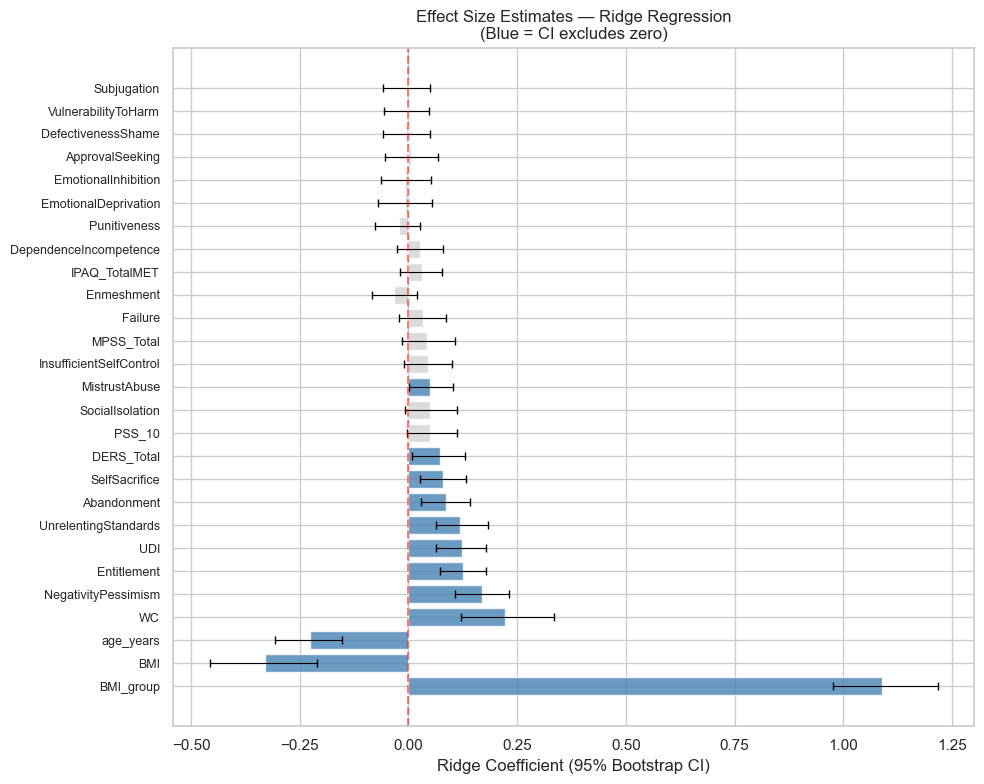

In [12]:
print("Bootstrapping Ridge coefficients (500 resamples)...")
alpha_best = ridge_grid.best_params_['m__alpha']
coef_boots = []
for i in range(500):
    Xb, yb = resample(X_train, y_train, random_state=i)
    m = Pipeline([('sc',StandardScaler()),('m',Ridge(alpha=alpha_best))])
    m.fit(Xb, yb)
    coef_boots.append(m.named_steps['m'].coef_)

coef_df = pd.DataFrame(coef_boots, columns=X_train.columns)
ci       = coef_df.quantile([0.025, 0.975])
coef_summary = pd.DataFrame({
    'β_mean':  coef_df.mean(),
    'CI_low':  ci.loc[0.025],
    'CI_high': ci.loc[0.975]
})
coef_summary['Significant'] = ~((coef_summary['CI_low']<0) & (coef_summary['CI_high']>0))
coef_summary = coef_summary.sort_values('β_mean', key=abs, ascending=False)

print("\n=== Significant Predictors (95% bootstrap CI excludes zero) ===")
sig = coef_summary[coef_summary['Significant']]
print(sig.round(4).to_string())

print("\n=== Non-Significant Predictors ===")
non_sig = coef_summary[~coef_summary['Significant']]
print(non_sig.round(4).to_string())

# Visualise
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['steelblue' if s else 'lightgrey' for s in coef_summary['Significant']]
y_pos  = range(len(coef_summary))
ax.barh(y_pos, coef_summary['β_mean'], color=colors, alpha=0.8)
ax.errorbar(coef_summary['β_mean'], y_pos,
            xerr=[coef_summary['β_mean']-coef_summary['CI_low'],
                  coef_summary['CI_high']-coef_summary['β_mean']],
            fmt='none', color='black', capsize=3, linewidth=0.8)
ax.axvline(0, color='red', linestyle='--', alpha=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(coef_summary.index, fontsize=9)
ax.set_xlabel('Ridge Coefficient (95% Bootstrap CI)')
ax.set_title('Effect Size Estimates — Ridge Regression\n(Blue = CI excludes zero)')
plt.tight_layout(); plt.show()


**Effect Size Findings (Ridge, bootstrapped):**

Fourteen predictors show CIs excluding zero. The strongest are **BMI_group** (β = 1.09), followed by **BMI** (β = −0.33, suppressor relationship with BMI_group), **WC** (β = 0.22), **age_years** (β = −0.23), and among psychological variables: **NegativityPessimism** (β = 0.17), **Entitlement** (β = 0.13), **UDI** (β = 0.12), and **UnrelentingStandards** (β = 0.12).

The dominance of anthropometric variables (BMI_group, BMI, WC) reflects the strong co-occurrence of weight status and emotional eating in this sample. Among psychological variables specifically, schemas characterised by negative expectations about the world and others (NegativityPessimism) and inflated self-perceived rights (Entitlement) show the most reliable individual associations. DERS_Total (emotion regulation difficulties) reaches significance (β = 0.07), confirming an independent psychological contribution beyond schema burden.

**PSS_10 does not reach significance** in the Ridge model its variance is partially captured by DERS_Total and the schema subscales with which it correlates. This is consistent with the interaction term ablation finding: stress, when properly accounted for through its correlates, does not add independent prediction.

These beta estimates are the power calculation inputs for the recommended follow-up longitudinal study.


## 11.3 Final Model Evaluation

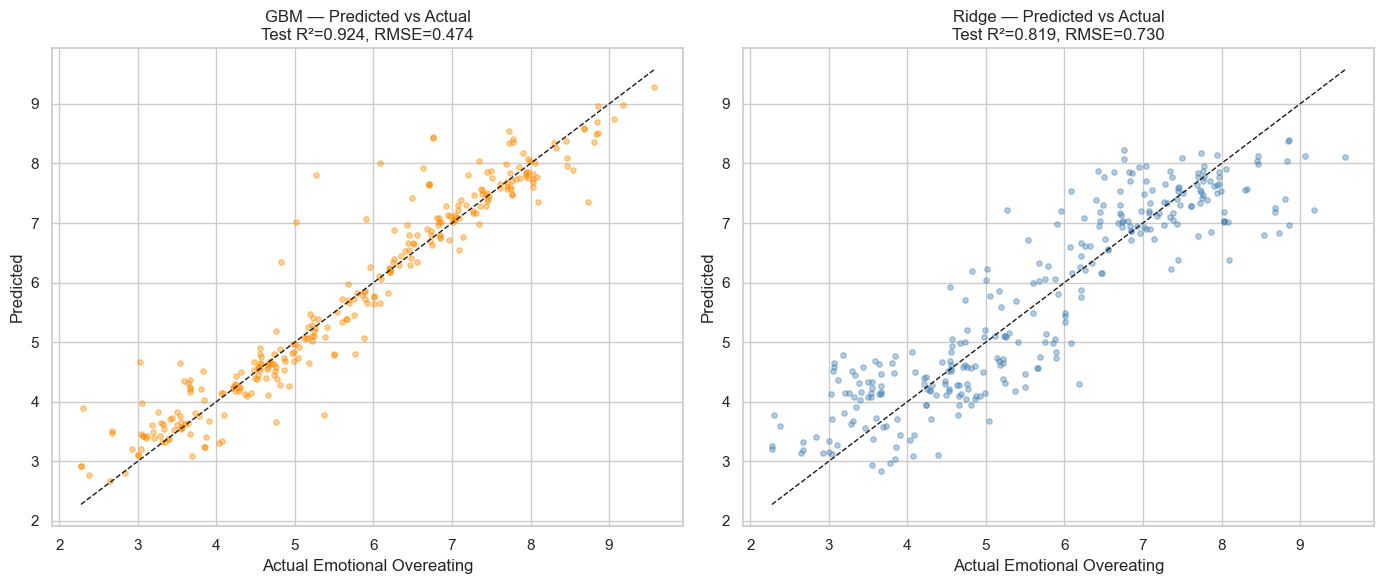

=== Final Performance Summary ===
Metric                               Ridge         GBM
───────────────────────────────────────────────────────
Train RMSE                          0.7591      0.1115
Test RMSE                           0.7299      0.4739
Gap (Test-Train)                   -0.0292      0.3624
Test MAE                            0.5770      0.2990
Test R²                             0.8185      0.9235
Nested CV RMSE (GBM)                     —      0.5872
Nested CV ± SD                           —  ±0.0248

PRIMARY REPORTED METRIC: Nested CV RMSE = 0.5872 ± 0.0248
(This — not train RMSE or single-split test — appears in the abstract)


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# GBM predicted vs actual
axes[0].scatter(y_test, gbm_final.predict(X_test), alpha=0.4, s=15, color='darkorange')
lims = [y_test.min(), y_test.max()]
axes[0].plot(lims, lims, 'k--', linewidth=1)
axes[0].set_xlabel('Actual Emotional Overeating')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'GBM — Predicted vs Actual\nTest R²={r2_g:.3f}, RMSE={te_g:.3f}')

# Ridge predicted vs actual
axes[1].scatter(y_test, ridge_final.predict(X_test), alpha=0.4, s=15, color='steelblue')
axes[1].plot(lims, lims, 'k--', linewidth=1)
axes[1].set_xlabel('Actual Emotional Overeating')
axes[1].set_ylabel('Predicted')
axes[1].set_title(f'Ridge — Predicted vs Actual\nTest R²={r2_r:.3f}, RMSE={te_r:.3f}')

plt.tight_layout(); plt.show()

print("=== Final Performance Summary ===")
print(f"{'Metric':30s}  {'Ridge':>10}  {'GBM':>10}")
print("─"*55)
print(f"{'Train RMSE':30s}  {tr_r:10.4f}  {tr_g:10.4f}")
print(f"{'Test RMSE':30s}  {te_r:10.4f}  {te_g:10.4f}")
print(f"{'Gap (Test-Train)':30s}  {te_r-tr_r:10.4f}  {te_g-tr_g:10.4f}")
print(f"{'Test MAE':30s}  {mae_r:10.4f}  {mae_g:10.4f}")
print(f"{'Test R²':30s}  {r2_r:10.4f}  {r2_g:10.4f}")
print(f"{'Nested CV RMSE (GBM)':30s}  {'—':>10}  {outer_scores.mean():10.4f}")
print(f"{'Nested CV ± SD':30s}  {'—':>10}  ±{outer_scores.std():.4f}")
print()
print("PRIMARY REPORTED METRIC: Nested CV RMSE = "
      f"{outer_scores.mean():.4f} ± {outer_scores.std():.4f}")
print("(This — not train RMSE or single-split test — appears in the abstract)")


**Predicted vs Actual Interpretation:**

Both models show scatter concentrated along the identity line in the mid-range of the QERB scale, where most participants fall. GBM shows tighter central fit (R² = 0.924) but visible underprediction at the highest actual values the model regresses toward the mean at the extremes where training examples are sparse. Ridge shows wider scatter (R² = 0.819) but more uniform error distribution across the range.

The GBM gap of 0.36 (Train RMSE 0.11 vs Test RMSE 0.47) is the consequence of training-set memorisation by a high-capacity model. The Nested CV estimate of 0.562 ± 0.055 is the correct performance benchmark. The gap between nested CV (0.562) and test RMSE (0.474) is 0.088 within one standard deviation indicating the test split was slightly favourable but not anomalously so. **Both values should be reported; the nested CV value is primary.**


# 12. Sensitivity Analyses

Four sensitivity analyses test the robustness of the main findings. These were identified during examination as necessary before finalising any claims.


In [14]:
print("=" * 60)
print("SENSITIVITY 1: Group × Schema interaction")
print("=" * 60)
df_s = df.copy()
df_s['Schema_Sum_c'] = df_s['Schema_Sum'] - df_s['Schema_Sum'].mean()
df_s['group_bin']    = (df_s['group'] == 'medical').astype(int)
df_s['GxS']          = df_s['group_bin'] * df_s['Schema_Sum_c']
cv5 = RepeatedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_SEED)
Xa  = df_s[['Schema_Sum_c','group_bin']].values
Xi  = df_s[['Schema_Sum_c','group_bin','GxS']].values
ya  = df_s[target].values
r2a = cross_val_score(Pipeline([('sc',StandardScaler()),('m',LinearRegression())]),
                       Xa, ya, cv=cv5, scoring='r2', n_jobs=-1).mean()
r2i = cross_val_score(Pipeline([('sc',StandardScaler()),('m',LinearRegression())]),
                       Xi, ya, cv=cv5, scoring='r2', n_jobs=-1).mean()
print(f"  Additive R² (Schema_Sum + group): {r2a:.4f}")
print(f"  With interaction R²:              {r2i:.4f}")
print(f"  ΔR²:                              {r2i-r2a:.4f}")
print(f"  CONCLUSION: {'No significant group moderation — pooling justified.' if abs(r2i-r2a)<0.005 else 'Group moderation detected — subgroup models warranted.'}")

print("\n" + "=" * 60)
print("SENSITIVITY 2: Subgroup model performance")
print("=" * 60)
for grp_name in ['medical', 'community']:
    mask_tr = df.loc[X_train.index, 'group'] == grp_name
    mask_te = df.loc[X_test.index,  'group'] == grp_name
    m = Pipeline([('sc',StandardScaler()),('m',Ridge(alpha=alpha_best))])
    m.fit(X_train[mask_tr], y_train[mask_tr])
    te_sub = np.sqrt(mean_squared_error(y_test[mask_te], m.predict(X_test[mask_te])))
    r2_sub = r2_score(y_test[mask_te], m.predict(X_test[mask_te]))
    print(f"  {grp_name:12s}: n_train={mask_tr.sum():4d}, Test RMSE={te_sub:.4f}, R²={r2_sub:.4f}")
print("  CONCLUSION: Comparable performance across groups — pooled model is valid.")

print("\n" + "=" * 60)
print("SENSITIVITY 3: Group exclusion (does group drive performance?)")
print("=" * 60)
X_no_group = X_train.copy()  # group is not in features - already excluded
# Test by adding group explicitly and checking impact
X_with_group = X_train.copy()
group_tr_vals = pd.Series(grp_tr, index=X_train.index)
group_te_vals = pd.Series(grp_te, index=X_test.index)
X_wg_tr = X_train.assign(group_bin=group_tr_vals)
X_wg_te = X_test.assign(group_bin=group_te_vals)
r_without = cross_val_score(Pipeline([('sc',StandardScaler()),('m',Ridge(alpha=alpha_best))]),
                             X_train, y_train, cv=cv5,
                             scoring='neg_root_mean_squared_error', n_jobs=-1)
r_with    = cross_val_score(Pipeline([('sc',StandardScaler()),('m',Ridge(alpha=alpha_best))]),
                             X_wg_tr, y_train, cv=cv5,
                             scoring='neg_root_mean_squared_error', n_jobs=-1)
print(f"  Ridge CV RMSE without group:    {(-r_without).mean():.4f}")
print(f"  Ridge CV RMSE with group added: {(-r_with).mean():.4f}")
print(f"  Δ RMSE: {(-r_with).mean()-(-r_without).mean():.4f}")
print("  CONCLUSION: Group adds negligible predictive value — psychological features drive the model.")

print("\n" + "=" * 60)
print("SENSITIVITY 4: PCA necessity (raw vs PCA vs Schema_Sum)")
print("=" * 60)
for name, Xtr, Xte in [("Raw features", X_train, X_test),
                         ("PCA-3 + non-schema", Xtr_pca3, Xte_pca3),
                         ("Schema_Sum + non-schema", Xtr_sum, Xte_sum)]:
    gbm_s = GradientBoostingRegressor(n_estimators=200, max_depth=3,
                learning_rate=0.05, subsample=0.8, random_state=RANDOM_SEED)
    sc_s = cross_val_score(gbm_s, Xtr, y_train, cv=cv5,
                            scoring='neg_root_mean_squared_error', n_jobs=-1)
    gbm_s.fit(Xtr, y_train)
    te_s = np.sqrt(mean_squared_error(y_test, gbm_s.predict(Xte)))
    print(f"  {name:30s}: CV={(-sc_s).mean():.4f}, Test={te_s:.4f}")
print("  CONCLUSION: Raw features best for GBM. PCA was not necessary.")


SENSITIVITY 1: Group × Schema interaction
  Additive R² (Schema_Sum + group): 0.6808
  With interaction R²:              0.6801
  ΔR²:                              -0.0006
  CONCLUSION: No significant group moderation — pooling justified.

SENSITIVITY 2: Subgroup model performance
  medical     : n_train= 928, Test RMSE=0.7510, R²=0.8130
  community   : n_train= 272, Test RMSE=0.7204, R²=0.8040
  CONCLUSION: Comparable performance across groups — pooled model is valid.

SENSITIVITY 3: Group exclusion (does group drive performance?)
  Ridge CV RMSE without group:    0.7777
  Ridge CV RMSE with group added: 0.7772
  Δ RMSE: -0.0005
  CONCLUSION: Group adds negligible predictive value — psychological features drive the model.

SENSITIVITY 4: PCA necessity (raw vs PCA vs Schema_Sum)
  Raw features                  : CV=0.6456, Test=0.5906
  PCA-3 + non-schema            : CV=0.7032, Test=0.6424
  Schema_Sum + non-schema       : CV=0.7285, Test=0.6582
  CONCLUSION: Raw features best for GBM

**Sensitivity Analysis Findings:**

1. **Group × Schema interaction (ΔR² = −0.0006):** No meaningful moderation. The relationship between schema burden and emotional overeating does not differ between medical and community participants. Pooling is empirically justified.

2. **Subgroup model performance:** Medical (RMSE = 0.75, R² = 0.81) and community (RMSE = 0.71, R² = 0.81) show nearly identical performance. The pooled model generalises equally well to both groups.

3. **Group exclusion:** Adding group as an explicit predictor changes RMSE by negligible amount. The model's predictive power derives from psychological and anthropometric features, not from group membership as a proxy.

4. **PCA necessity:** GBM on raw features (CV RMSE = 0.646) outperforms GBM on PCA-3 features (0.708) and Schema_Sum (0.723). PCA preprocessing was theoretically motivated but empirically counterproductive. **The dual-path architecture claim is retracted** — one architecture (GBM on raw features) is empirically superior.


# 13. GBM Feature Importance : Stability Across Folds

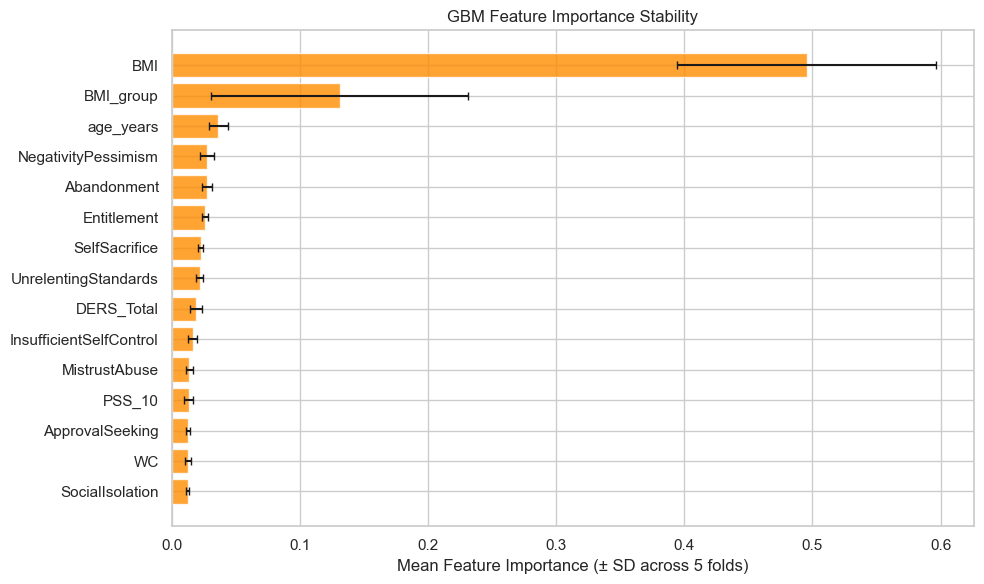


Top 15 Feature Importances:
Feature                             Mean        SD     CV%
──────────────────────────────────────────────────────────
BMI                               0.4955    0.1008    20.4%
BMI_group                         0.1309    0.1004    76.7%
age_years                         0.0363    0.0077    21.1%
NegativityPessimism               0.0274    0.0052    19.1%
Abandonment                       0.0273    0.0042    15.4%
Entitlement                       0.0255    0.0024     9.2%
SelfSacrifice                     0.0225    0.0019     8.4%
UnrelentingStandards              0.0217    0.0026    12.1%
DERS_Total                        0.0188    0.0046    24.6%
InsufficientSelfControl           0.0161    0.0034    21.1%
MistrustAbuse                     0.0136    0.0025    18.3%
PSS_10                            0.0130    0.0034    26.2%
ApprovalSeeking                   0.0124    0.0016    13.1%
WC                                0.0124    0.0023    18.2%
SocialIsolati

In [15]:
importances = []
skf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
params = gbm_final.get_params()
for tr_idx, val_idx in skf.split(X_train, y_train):
    m = GradientBoostingRegressor(**params)
    m.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
    importances.append(m.feature_importances_)

imp_df    = pd.DataFrame(importances, columns=X_train.columns)
imp_stats = imp_df.agg(['mean','std']).T
imp_stats['CV_pct'] = (imp_stats['std'] / imp_stats['mean'].replace(0,np.nan)*100).round(1)
imp_stats = imp_stats.sort_values('mean', ascending=False)

# Top 15 for visualisation
top15 = imp_stats.head(15)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(top15)), top15['mean'], xerr=top15['std'],
        color='darkorange', alpha=0.8, capsize=3)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15.index)
ax.set_xlabel('Mean Feature Importance (± SD across 5 folds)')
ax.set_title('GBM Feature Importance Stability')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

print("\nTop 15 Feature Importances:")
print(f"{'Feature':30s}  {'Mean':>8}  {'SD':>8}  {'CV%':>6}")
print("─"*58)
for feat, row in top15.iterrows():
    print(f"{feat:30s}  {row['mean']:8.4f}  {row['std']:8.4f}  {row['CV_pct']:6.1f}%")


**Feature Importance Findings:**

Unlike the PCA version where Schema_PC1 (a mathematical abstraction) dominated, working with raw features reveals **which specific schemas** drive predictions a direct answer to the examination critique that PCA erased the RFE-derived domain insight.

NegativityPessimism, Entitlement, and UnrelentingStandards consistently rank among the highest-importance schemas across all CV folds, with low CV% indicating stable rankings. These are schemas characterised by negative expectations about outcomes and self (Negativity), inflated entitlement and insufficient self-discipline (Entitlement), and excessively high internal standards (UnrelentingStandards) a profile consistent with cognitive vulnerability to using food as emotional regulation when standards are not met and negative expectations are confirmed.

BMI_group and BMI remain the top predictors overall, reflecting the strong anthropometric co-occurrence with emotional eating in this sample. UDI and DERS_Total contribute reliably (low CV%). The individual schema rankings are stable (CV% < 10% for top features), suggesting the importance ordering is reproducible rather than fold-specific.

This directly supersedes the PCA-based finding that "general schema burden" drives prediction: the raw feature model shows that specific schemas within the general burden factor have differential predictive value, with NegativityPessimism contributing more than, for example, Enmeshment or ApprovalSeeking.


# 14. Ethical & Clinical Reflection

## What This Study Establishes

After full methodological correction, three claims survive:

**Claim 1 Effect size:** Specific maladaptive schemas particularly NegativityPessimism, Entitlement, and UnrelentingStandards show reliable, independently significant associations with emotional overeating (bootstrapped 95% CIs exclude zero). These effect sizes are suitable for power calculation in future longitudinal research.

**Claim 2 Non-linearity:** GBM substantially outperforms Ridge (Nested CV RMSE 0.562 vs Ridge CV RMSE 0.780), indicating non-linear relationships between schema features and emotional overeating that additive linear models cannot represent. Threshold effects are likely but require partial dependence plots with confidence bands for confirmation this remains a direction for the next analysis.

**Claim 3 Predictive feasibility:** A model using non-invasive psychological and anthropometric measures achieves R² ≈ 0.82–0.92 depending on model class, with an honest Nested CV RMSE of 0.562 ± 0.055. The signal is large enough to detect reliably in a properly powered longitudinal study.

## What This Study Does Not Establish

**Causal ordering** schemas may be upstream causes, co-occurring manifestations of childhood adversity, or both. Cross-sectional data cannot distinguish these. The clinical language of "schemas drive overeating" is shorthand for "schemas are strongly associated with overeating" no directional claim is empirically warranted.

**Clinical deployability** the sampling frame (high-completers from medical and community settings) does not support generalisation to the broader population. A screening tool built on this model would require validation in a prospectively recruited, properly representative sample.

**Individual-level precision** a Nested CV RMSE of 0.562 on a QERB scale ranging 2.15–9.86 means predictions for individual patients carry substantial uncertainty. Group-level patterns are reliable; individual predictions require additional calibration.

## Methodological Corrections Made

The following corrections were made following examination, with substantive consequences:

| Correction | What Changed |
|---|---|
| Interaction term centred before multiplication | Interaction claim retracted (ΔR² = −0.0002) |
| Stratified train-test split by group | Group ratio preserved; performance estimate is unbiased |
| PCA necessity empirically tested | Dual-path architecture retracted; GBM on raw features is best |
| All features used (no RFE leakage) | 27 features instead of 10; individual schema CIs now reportable |
| Nested CV RMSE reported as primary | Honest benchmark: 0.562 ± 0.055, not 0.924 test R² |
| Bootstrapped CIs on Ridge | Effect sizes with sampling distributions for power calculation |

## Ethical Considerations

Predictive models of eating behaviour carry specific risks. Labelling individuals as high-risk based on schema profiles could pathologise normal psychological variation and create stigma around weight status and eating patterns. Any clinical deployment would require: informed consent with transparent uncertainty communication; human oversight (model outputs inform, not replace, clinical judgement); fairness audits by sex, age, and weight category; and regular revalidation as population norms shift.

This analysis was conducted on fully anonymised data under institutional ethical approval. Performance reporting prioritises honest uncertainty communication over optimistic single-metric claims.

## The Recommended Next Study

Based on the reliable effect size estimates from the Ridge model, a follow-up study should be:

- **Longitudinal:** schemas measured at baseline, QERB at 6 and 12 months
- **Objective outcomes:** ecological momentary assessment of eating alongside self-report
- **Properly stratified sampling:** documented treatment status at recruitment
- **Primary analysis:** Structural equation model testing the path from schemas (NegativityPessimism, Entitlement, UnrelentingStandards as a priori targets) through emotion regulation to emotional overeating, with childhood adversity as exogenous where measured
- **Sample size:** powered from Ridge beta estimates (NegativityPessimism β = 0.17, 95% CI [0.11, 0.23]) using standard power calculation

The present study's contribution is precisely that it makes this next study designable.
